<a href="https://colab.research.google.com/github/AnanyaAsthana/Digital-Image-Processing/blob/main/DIP_LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving cute2.jpg to cute2.jpg
Saving cute.jpg to cute.jpg


(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

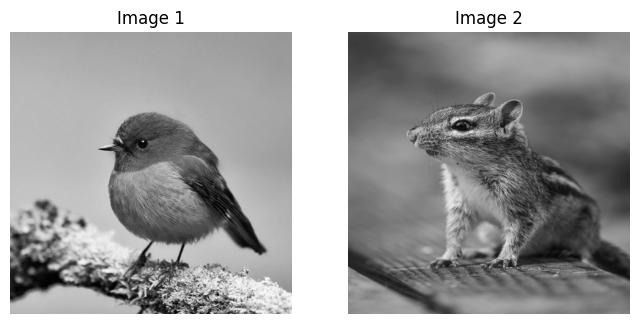

In [ ]:
uploaded = files.upload()

images = list(uploaded.keys())

if len(images) < 2:
    if len(images) == 0:
        print("No images uploaded. Please upload at least one image.")
        raise ValueError("No images uploaded.")
    else: # len(images) == 1
        print("Only one image uploaded. Using the same image for both 'Image 1' and 'Image 2'.")
        img1 = cv2.imread(images[0],0)
        img2 = img1.copy() # Use a copy to avoid unintended modifications
else: # len(images) >= 2
    img1 = cv2.imread(images[0],0)
    img2 = cv2.imread(images[1],0)

img2 = cv2.resize(img2,(img1.shape[1],img1.shape[0]))

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(img1,cmap='gray')
plt.title("Image 1")
plt.axis("off")

plt.subplot(122)
plt.imshow(img2,cmap='gray')
plt.title("Image 2")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

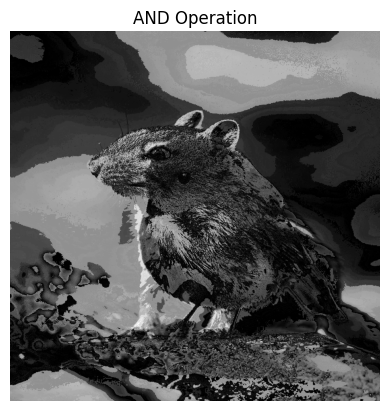

In [ ]:
and_img = cv2.bitwise_and(img1,img2)

plt.imshow(and_img,cmap='gray')
plt.title("AND Operation")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

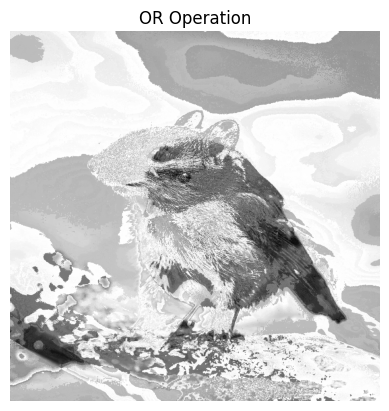

In [ ]:
or_img = cv2.bitwise_or(img1,img2)

plt.imshow(or_img,cmap='gray')
plt.title("OR Operation")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

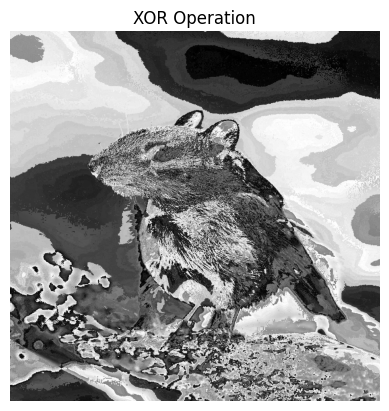

In [ ]:
xor_img = cv2.bitwise_xor(img1,img2)

plt.imshow(xor_img,cmap='gray')
plt.title("XOR Operation")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

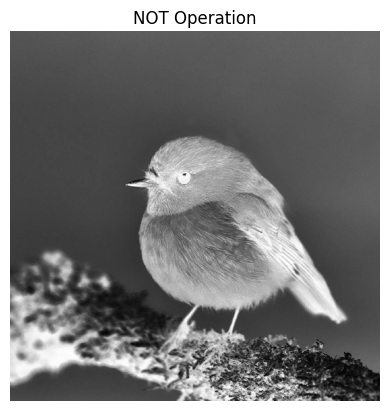

In [ ]:
not_img = cv2.bitwise_not(img1)

plt.imshow(not_img,cmap='gray')
plt.title("NOT Operation")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

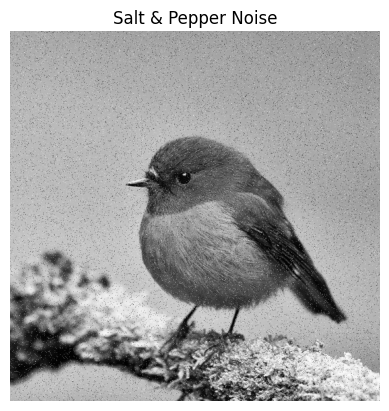

In [ ]:
def add_salt_pepper_noise(image,prob):

    noisy = np.copy(image)

    salt = np.random.rand(*image.shape) < prob
    pepper = np.random.rand(*image.shape) < prob

    noisy[salt] = 255
    noisy[pepper] = 0

    return noisy

noisy_img = add_salt_pepper_noise(img1,0.02)

plt.imshow(noisy_img,cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

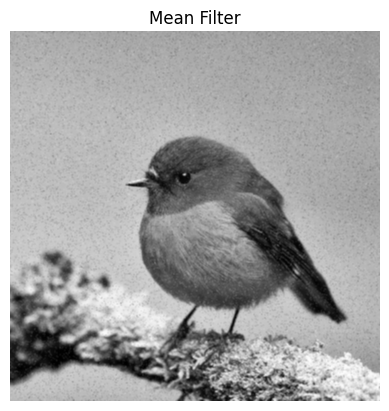

In [ ]:
mean_filter = cv2.blur(noisy_img,(5,5))

plt.imshow(mean_filter,cmap='gray')
plt.title("Mean Filter")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

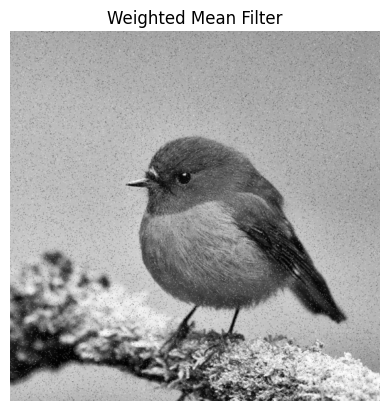

In [ ]:
kernel = np.array([[1,2,1],
                   [2,4,2],
                   [1,2,1]])/16

weighted_mean = cv2.filter2D(noisy_img,-1,kernel)

plt.imshow(weighted_mean,cmap='gray')
plt.title("Weighted Mean Filter")
plt.axis("off")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

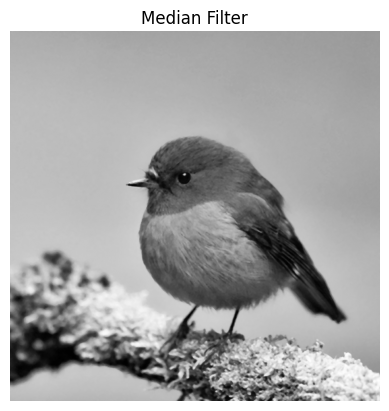

In [ ]:
median = cv2.medianBlur(noisy_img,5)

plt.imshow(median,cmap='gray')
plt.title("Median Filter")
plt.axis("off")

Text(0.5, 1.0, 'Laplacian Sharpened')

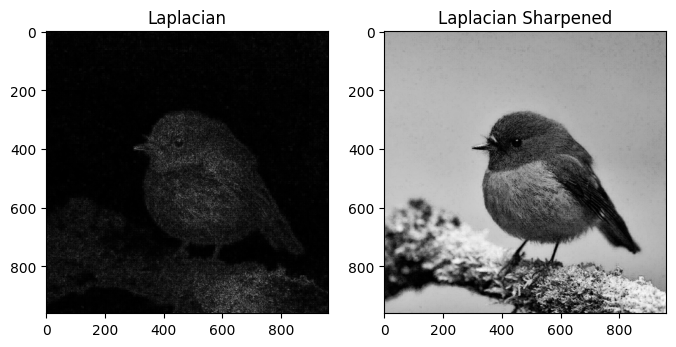

In [ ]:
laplacian = cv2.Laplacian(img1,cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

sharpened = cv2.subtract(img1,laplacian)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(laplacian,cmap='gray')
plt.title("Laplacian")

plt.subplot(122)
plt.imshow(sharpened,cmap='gray')
plt.title("Laplacian Sharpened")

Text(0.5, 1.0, 'Unsharp Masking')

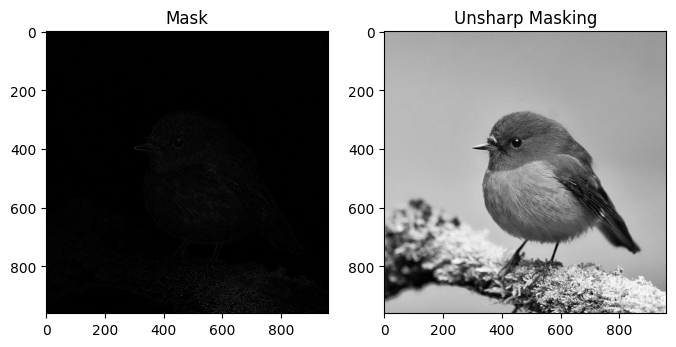

In [ ]:
blur = cv2.GaussianBlur(img1,(5,5),0)

mask = cv2.subtract(img1,blur)

unsharp = cv2.add(img1,mask)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(mask,cmap='gray')
plt.title("Mask")

plt.subplot(122)
plt.imshow(unsharp,cmap='gray')
plt.title("Unsharp Masking")

(np.float64(-0.5), np.float64(959.5), np.float64(959.5), np.float64(-0.5))

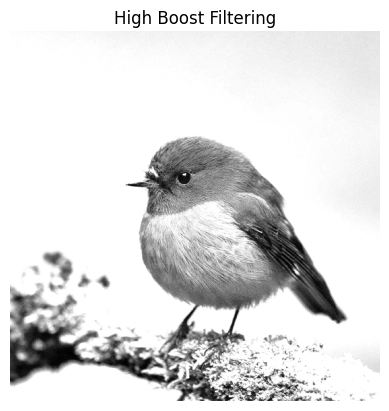

In [ ]:
A = 1.5

blur = cv2.GaussianBlur(img1,(5,5),0)

mask = cv2.subtract(img1,blur)

high_boost = cv2.addWeighted(img1,A,mask,1,0)

plt.imshow(high_boost,cmap='gray')
plt.title("High Boost Filtering")
plt.axis("off")